# 📚 Learning Path: Graphs, LLMs, and Knowledge Extraction with Historical Data
Welcome to this hands-on notebook! This guided journey is designed for beginners in both knowledge graphs and large language models (LLMs). By the end, you will:
- Understand what a knowledge graph is and why it matters for reasoning over data.
- Learn how to use LLMs to extract structured knowledge from unstructured text.
- See how to build, query, and visualize a knowledge graph from historical data.
- Practice asking questions and interpreting answers using both graph and LLM reasoning.
- Reflect on each step with learner prompts to deepen your understanding.

**How to use this notebook:**
- Read the explanations and learner comments in each cell.
- Run the code cells in order, and observe the outputs.
- After each section, pause to consider the learner prompts and questions.
- Try modifying the code or data to experiment and learn actively!

Let's begin your journey into the world of graphs and LLMs!

# 🧠 Historical GraphRAG Notebook
Welcome! In this notebook, you'll learn how to combine knowledge graphs and large language models (LLMs) to extract, organize, and reason about information from historical texts.

**What is a Knowledge Graph?**
A knowledge graph is a way to represent information as a network of entities (like people, places, or events) and the relationships between them. This makes it easier to explore connections and answer complex questions.

**Why use LLMs?**
LLMs can help us extract structured knowledge (facts and relationships) from unstructured text, making it possible to build and update knowledge graphs automatically.

As you go through each step, look for the learner prompts and questions to help you reflect and deepen your understanding.

## 🔧 Environment Setup
Before we start, let's make sure we have all the necessary tools. We'll use several Python libraries:
- `langchain` and `langchain-core`: For working with LLMs and building chains of reasoning.
- `pandas`: For handling tabular data.
- `networkx`: For building and visualizing graphs.
- `dotenv`: For securely loading API keys and settings.

**Learner Prompt:**
- Why do you think we need both a graph library and an LLM library? What might each be responsible for in this project?

In [64]:
# 🚀 Colab Setup — install Ollama + pull a small model
import subprocess, time

# Install zstd (required by Ollama's installer on Colab)
!apt-get install -y zstd > /dev/null 2>&1

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Start the Ollama server in background
subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(3)

# Pull a small but capable model
!ollama pull qwen2:0.5b

print('✅ Ollama ready!')


>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

✅ Ollama ready!


In [65]:
# Uninstall conflicting legacy packages pre-installed in Colab
!pip uninstall -q -y langchain-classic 2>/dev/null || true

%pip install -q langchain langchain-community langchain-ollama \
    "langchain-core>=0.3.0,<1.0.0" "langchain-text-splitters>=0.3.0,<1.0.0" \
    networkx pandas python-dotenv "requests==2.32.4"

In [66]:
# Import all the libraries we need for this project.
import os  # For interacting with the operating system and environment variables
import pandas as pd  # For loading and manipulating tabular data
import networkx as nx  # For creating and working with graphs
from collections import defaultdict  # For counting and grouping data efficiently
from langchain_ollama import ChatOllama  # For using local Ollama LLM
from langchain_core.prompts import PromptTemplate  # For creating prompts for the LLM
from langchain_core.output_parsers import StrOutputParser  # For parsing LLM outputs
from langchain_text_splitters import RecursiveCharacterTextSplitter  # For splitting text into manageable chunks
from langchain.schema import Document  # For working with document objects
from dotenv import load_dotenv  # For loading environment variables from a .env file
import matplotlib.pyplot as plt  # For visualizing the knowledge graph

# Load environment variables (like API keys) from a .env file for security.
load_dotenv()

# Learner Prompt:
# - Can you identify which libraries are for graphs, which are for LLMs, and which are for data handling?

False

## 🤖 LLM Setup (Ollama — runs locally, no API key needed)
We use Ollama to run a small local LLM completely free, right in this Colab session. No API keys needed!

**Learner Prompt:**
- What are the advantages and tradeoffs of running a local LLM vs. a cloud API?

In [67]:
# No API keys needed — Ollama runs locally!
# All LLM calls go to your local Ollama server at http://localhost:11434
print('✅ Using local Ollama — no credentials required')


✅ Using local Ollama — no credentials required


In [68]:
# Load the local LLM via Ollama — runs entirely in this Colab session.
# This model will help us extract knowledge from text and answer questions.
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model="qwen2:0.5b",
    base_url="http://localhost:11434",
    temperature=0.7
)

# Learner Prompt:
# - What do you think happens if you set the temperature to 0? To 2? Try changing it and see what kind of responses you get.

## 📄 Load and Chunk Historical Text
To build a knowledge graph, we first need to load our historical data. We'll use a CSV file with information about historical figures. Because LLMs work best with short pieces of text, we'll split the data into manageable chunks.

**Learner Prompt:**
- Why do you think it's important to split long documents into smaller chunks before processing them with an LLM?

In [69]:
# Historical data embedded directly — no external file needed!
# This makes the notebook fully self-contained and Colab-friendly.
from langchain.schema import Document

historical_texts = [
    "Albert Einstein developed the theory of relativity and influenced the development of quantum mechanics.",
    "Marie Curie discovered polonium and radium, significantly advancing radioactivity research.",
    "The Manhattan Project was a secret U.S. project during World War II that developed the atomic bomb.",
    "Isaac Newton formulated the laws of motion and universal gravitation.",
    "Galileo Galilei improved the telescope and supported heliocentrism despite opposition from the Catholic Church.",
    "The discovery of penicillin by Alexander Fleming marked the beginning of modern antibiotics.",
    "Charles Darwin published 'On the Origin of Species' and introduced the theory of evolution through natural selection.",
    "Nikola Tesla contributed to the development of alternating current (AC) electricity systems.",
    "Ada Lovelace is considered the first computer programmer for her work on Charles Babbage's Analytical Engine.",
    "The Apollo 11 mission in 1969, led by NASA, resulted in the first human landing on the Moon.",
    "The Manhattan Project researched topics like the theory of relativity and quantum mechanics.",
]

docs = [Document(page_content=text) for text in historical_texts]

# Split the documents into smaller chunks for easier processing by the LLM.
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
documents = splitter.split_documents(docs)

# Learner Prompt:
# - What might happen if you use a very large chunk size? What about a very small one?


## 🏗️ Entity Extraction Prompt (with Example)
Now we'll use the LLM to extract structured knowledge from our text. We'll ask it to find entities (like people or events) and the relationships between them, and return these as triples (Subject, Predicate, Object).
This is a key step in building a knowledge graph from unstructured data.

**Learner Prompt:**
- Why do you think we use the format (Subject, Predicate, Object) for representing knowledge? Can you think of an example from your own experience?

In [70]:
# Create a prompt template for the LLM to extract triples and new entities from text.
dynamic_entity_prompt = PromptTemplate.from_template("""
You are an expert in information extraction. Analyze the following text and extract factual triples and new entities.

Extract factual triples and new entities from the following text.

- Return the triples as plain lines in the format: Subject, Predicate, Object
- Do not use dashes, bullets, or numbering.
- Avoid extra punctuation like periods at the end.
- Return the new entities as a plain list, one per line.
- Do not include the triples in the entity list.

Text:
{input}

Known Entities:
{known}

Respond in this format exactly:

Triples:
Subject1, Predicate1, Object1
Subject2, Predicate2, Object2

New Entities:
Entity1
Entity2
Entity3
""")
dynamic_entity_chain = dynamic_entity_prompt | llm | StrOutputParser()

# Learner Prompt:
# - Why is it important to be very specific about the output format when working with LLMs?

## 🌐 Build Knowledge Graph from Triples
Once we have extracted triples (facts) from the text, we can build a knowledge graph. Each triple becomes a connection (edge) between two entities (nodes) in the graph.
This graph structure allows us to explore relationships and answer questions that would be hard to solve with plain text.

**Learner Prompt:**
- How might a knowledge graph help you find connections between historical figures that aren't obvious from reading text alone?

In [71]:
# Build the knowledge graph from the extracted triples.
import os
import time
import json
from networkx.readwrite import json_graph

# === CONFIG ===
REINDEX = True  # Set to False to skip LLM re-indexing if data exists
GRAPH_PATH = "historical_graph.json"
ENTITIES_PATH = "known_entities.json"

# === Setup containers ===
G = nx.MultiDiGraph()
all_triples = []
entity_usage = defaultdict(int)
known_entities = set()
MAX_ENTITIES_FOR_PROMPT = 40

if not REINDEX and os.path.exists(GRAPH_PATH) and os.path.exists(ENTITIES_PATH):
    print("🔁 Loading graph and entities from disk...")
    with open(GRAPH_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)
        G = json_graph.node_link_graph(data, directed=True, multigraph=True)
    with open(ENTITIES_PATH, "r", encoding="utf-8") as f:
        known_entities = set(json.load(f))
    print(f"✅ Loaded graph with {len(G.nodes)} nodes and {len(G.edges)} edges.")
else:
    print("⚙️ Rebuilding graph from documents using LLM...")
    for i, doc in enumerate(documents):
        start = time.time()

        # Sort known entities by usage to prioritize important ones for the prompt.
        sorted_entities = sorted(known_entities, key=lambda e: -entity_usage[e])
        limited_entities = sorted_entities[:MAX_ENTITIES_FOR_PROMPT]
        known_str = ", ".join(limited_entities) if limited_entities else "(none)"

        # Use the LLM to extract triples and new entities from each document chunk.
        output = dynamic_entity_chain.invoke({"input": doc.page_content, "known": known_str})
        print(f"\n--- LLM Output for doc {i} ---\n{output.strip()}")

        # Split the output into triples and new entities.
        sections = output.strip().split("New Entities:")
        triples_block = sections[0].replace("Triples:", "").strip()
        new_entities_block = sections[1].strip() if len(sections) > 1 else ""

        triples = []
        for line in triples_block.split("\n"):
            if line.strip():
                parts = [p.strip(" ()\n") for p in line.split(",")]
                if len(parts) == 3:
                    triples.append(tuple(parts))
                else:
                    print(f"⚠️ Skipping malformed triple line: {line}")

        # Normalize new entities by stripping leading/trailing spaces and quotes
        new_entities = [e.lstrip("- ").strip(" \"'\n") for e in new_entities_block.split("\n") if e.strip()]

        all_triples.extend(triples)
        known_entities.update(new_entities)

        for s, r, o in triples:
            # Normalize subject and object by stripping leading/trailing spaces and hyphens
            s = s.lstrip("- ").strip()
            r = r.strip(" .-").lower()
            o = o.lstrip("- ").strip()
            G.add_node(s)
            G.add_node(o)
            G.add_edge(s, o, relation=r)
            entity_usage[s] += 1
            entity_usage[o] += 1

        print(f"⏱️ Processed doc {i} in {round(time.time() - start, 2)}s")

    # === Save graph and entity index ===
    print("💾 Saving graph and entities to disk...")
    with open(GRAPH_PATH, "w", encoding="utf-8") as f:
        json.dump(json_graph.node_link_data(G), f, ensure_ascii=False, indent=2)
    with open(ENTITIES_PATH, "w", encoding="utf-8") as f:
        json.dump(sorted(list(known_entities)), f, ensure_ascii=False, indent=2)

    print(f"✅ Graph built with {len(G.nodes)} nodes, {len(G.edges)} edges, and {len(known_entities)} tracked entities.")

# Learner Prompt:
# - What are some advantages of storing the graph and entities to disk? When might you want to rebuild the graph from scratch?

⚙️ Rebuilding graph from documents using LLM...

--- LLM Output for doc 0 ---
Triples: 
(Einstein, developed the theory of relativity, Albert)
(People, influenced the development of quantum mechanics)

New Entities: 
(Entity1, Theoretical physicist)  
(Entity2, Albert Einstein)
⚠️ Skipping malformed triple line: (People, influenced the development of quantum mechanics)
⏱️ Processed doc 0 in 20.61s

--- LLM Output for doc 1 ---
Triples:
Marie Curie, discovered polonium and radium, significantly advancing radioactivity research.
Albert Einstein, Albert Einstein, Theoretical physicist.

New Entities:
Polonium (Entity1), Radium (Entity2).
⏱️ Processed doc 1 in 6.32s

--- LLM Output for doc 2 ---
Triples:
Subject1, Subject2, Predicate1
Subject2, Subject2, Predicate2
Object1, Object2
Radium, Theoretical physicist
The Manhattan Project
Albert Einstein, Polonium Entity1
Polonium, Entity2
⚠️ Skipping malformed triple line: Object1, Object2
⚠️ Skipping malformed triple line: Radium, Theoretical 

In [72]:
# Alternative function: directed BFS search (preserves edge direction).
def search_graph_directed(anchor_entity: str, depth: int = 2) -> nx.MultiDiGraph:
    if anchor_entity not in G:
        raise ValueError(f"Entity '{anchor_entity}' not found in the graph.")

    # Use BFS to find all nodes within the specified depth
    bfs_edges = nx.bfs_edges(G, source=anchor_entity, depth_limit=depth)
    nodes_in_scope = {anchor_entity}
    edges_in_scope = []

    for u, v in bfs_edges:
        nodes_in_scope.update([u, v])
        edges_in_scope.append((u, v))

    # Create a new subgraph from the collected nodes and edges
    subgraph = nx.MultiDiGraph()
    for u, v in edges_in_scope:
        for key in G[u][v]:
            relation = G[u][v][key].get("relation", "")
            subgraph.add_edge(u, v, relation=relation)
            subgraph.add_node(u)
            subgraph.add_node(v)

    return subgraph

# Learner Prompt:
# - Why might you want to limit the depth of your search in a large graph? What could happen if you set the depth too high?

In [73]:
# Alternative function: search the graph in an undirected way (ignoring edge direction).
import re as _re

def _camel_split(text):
    """Split CamelCase/PascalCase into words: 'AlbertEinstein' → 'albert einstein'"""
    spaced = _re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    return spaced.lower()

def _node_word_score(anchor_words, node):
    node_words = set(_re.findall(r"[a-z]+", _camel_split(node)))
    if not node_words or not anchor_words:
        return 0
    return len(anchor_words & node_words) / max(len(anchor_words), len(node_words))

def search_graph(anchor: str, depth: int = 2) -> nx.Graph:
    nonlocal_anchor = anchor
    if anchor not in G:
        # Fuzzy fallback: find closest graph node by word overlap
        anchor_words = set(w for w in _re.findall(r"[a-z]+", _camel_split(anchor)) if len(w) > 2)
        best_node, best_score = None, 0.0
        for node in G.nodes():
            score = _node_word_score(anchor_words, node)
            if score > best_score:
                best_score, best_node = score, node
        if best_node and best_score >= 0.25:
            print(f"ℹ️  \'{anchor}\' not in graph — using closest node: \'{best_node}\' (score {best_score:.2f})")
            nonlocal_anchor = best_node
        else:
            print(f"⚠️  Entity \'{anchor}\' not found in graph. Known nodes: {list(G.nodes())[:10]}")
            return nx.Graph()

    undirected_G = G.to_undirected()
    visited_nodes = set([nonlocal_anchor])
    current_level = set([nonlocal_anchor])

    for _ in range(depth):
        next_level = set()
        for node in current_level:
            neighbors = undirected_G.neighbors(node)
            for neighbor in neighbors:
                if neighbor not in visited_nodes:
                    next_level.add(neighbor)
        visited_nodes.update(next_level)
        current_level = next_level

    subgraph = G.subgraph(visited_nodes).copy()
    return subgraph

# Learner Prompt:
# - What is the difference between a directed and undirected graph? When might you want to ignore edge direction?


## 📌 Anchor Detection from Question
When you ask a question, we need to figure out which entity in the graph is most relevant (the "anchor"). We'll use the LLM to match your question to the best entity.

**Learner Prompt:**
- Why do you think it's helpful to identify an anchor entity before searching the graph?

In [74]:
# Function to detect the main entity (anchor) in a user's question.
# Uses word-overlap scoring (no LLM) for reliable matching even with small models.
import re as _re2

def detect_anchor_entity(question: str) -> str:
    """Find the best matching entity from the graph for the given question."""
    question_lower = question.lower()
    question_words = set(w for w in _re2.findall(r"[a-z]+", question_lower) if len(w) > 2)

    sorted_entities = sorted(known_entities, key=lambda e: -entity_usage.get(e, 0))
    best_entity, best_score = None, 0.0

    for entity in sorted_entities:
        # Normalize entity name: split CamelCase, lowercase
        normalized = _re2.sub(r"([a-z])([A-Z])", r"\1 \2", entity).lower()
        entity_words = [w for w in _re2.findall(r"[a-z]+", normalized) if len(w) > 3]
        if not entity_words:
            continue
        # Score = fraction of entity words found in question
        score = sum(1 for w in entity_words if w in question_words) / len(entity_words)
        if score > best_score:
            best_score, best_entity = score, entity

    if best_entity and best_score > 0:
        print(f"✅ Detected anchor entity: {best_entity} (score: {best_score:.2f})")
        return best_entity

    # Last resort: most-used entity
    if sorted_entities:
        fallback = sorted_entities[0]
        print(f"⚠️  No match found for question — defaulting to most-used entity: {fallback}")
        return fallback

    return list(known_entities)[0] if known_entities else ""

# Learner Prompt:
# - What challenges might arise when matching question words to entity names extracted by an LLM?


In [75]:
# Visualize the subgraph around the detected anchor entity to see its connections.
def visualize_subgraph(query: str, depth: int = 2):
    anchor_entity = detect_anchor_entity(query)
    print(f"🔍 Detected anchor entity: {anchor_entity}")

    if anchor_entity not in G:
        print(f"⚠️ Entity '{anchor_entity}' not found in the graph.")
        return

    # Extract the subgraph based on depth
    visited = set()
    queue = [(anchor_entity, 0)]
    sub_nodes = set()

    while queue:
        current_node, current_depth = queue.pop(0)
        if current_depth > depth or current_node in visited:
            continue
        visited.add(current_node)
        sub_nodes.add(current_node)
        neighbors = list(G.successors(current_node)) + list(G.predecessors(current_node))
        for neighbor in neighbors:
            queue.append((neighbor, current_depth + 1))
            sub_nodes.add(neighbor)

    SG = G.subgraph(sub_nodes)

    # Visualize
    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(SG, seed=42)
    nx.draw_networkx_nodes(SG, pos, node_size=600, node_color="#FFEEEE")
    nx.draw_networkx_edges(SG, pos, arrows=True, arrowstyle='-|>', edge_color="#666")
    nx.draw_networkx_labels(SG, pos, font_size=10)
    edge_labels = {(u, v): data["relation"] for u, v, data in SG.edges(data=True)}
    nx.draw_networkx_edge_labels(SG, pos, edge_labels=edge_labels, font_size=9)
    plt.title(f"Subgraph for: '{anchor_entity}'", fontsize=14)
    plt.axis("off")
    plt.show()

# Learner Prompt:
# - How does visualizing a subgraph help you understand the relationships between entities?

## 🤔 Ask a Question Using the Graph
Now you can ask questions about historical figures or events. The system will use the knowledge graph to find relevant facts and help the LLM answer your question.

**Learner Prompt:**
- How might the answers you get from a knowledge graph differ from those you get from a search engine or a plain LLM?

In [76]:
# Use the knowledge graph to answer a question by extracting relevant facts and passing them to the LLM.
def answer_question_with_graph(query: str, depth: int = 2):
    anchor_entity = detect_anchor_entity(query)
    print(f"🔍 Detected anchor entity: {anchor_entity}")

    subgraph = search_graph(anchor_entity, depth=depth)
    context = [f"{u} {data['relation']} {v}." for u, v, data in subgraph.edges(data=True)]
    context_text = "\n".join(context)

    response = llm.invoke(f"Answer the question based on these facts:\n\n{context_text}\n\nQuestion: {query}")

    return context, response.content

# Learner Prompt:
# - What are the advantages of providing the LLM with a focused set of facts from the graph, instead of the entire dataset?

## 🚀 Try It Out
Now it's your turn! Try asking your own questions about the historical data. Experiment with different questions and see how the graph and LLM work together to provide answers.

**Learner Prompt:**
- What kinds of questions work best with this system? What are its limitations?

✅ Detected anchor entity: Albert Einstein (score: 1.00)
🔍 Detected anchor entity: Albert Einstein

Retrieved Chunks:
- Albert Einstein albert einstein Theoretical physicist..
- Albert Einstein theoretical physicist(t7 Albert Einstein(T8.

Answer:
Albert Einstein contributed significantly to the development of the atomic bomb. He was a key figure in the Manhattan Project, a United States government program designed to build atomic bombs for the Allies during World War II. The project involved the creation of the first hydrogen bomb (also known as the Manhattan Project's Hiroshima bomb) which was detonated on August 6, 1945 by President Franklin D. Roosevelt and General Douglas MacArthur.

In addition to his contributions to the development of atomic bombs, Albert Einstein also played a key role in the development of nuclear energy and research, particularly in the fields of physics and chemistry. He is considered one of the greatest scientists of all time and remains one of the most inf

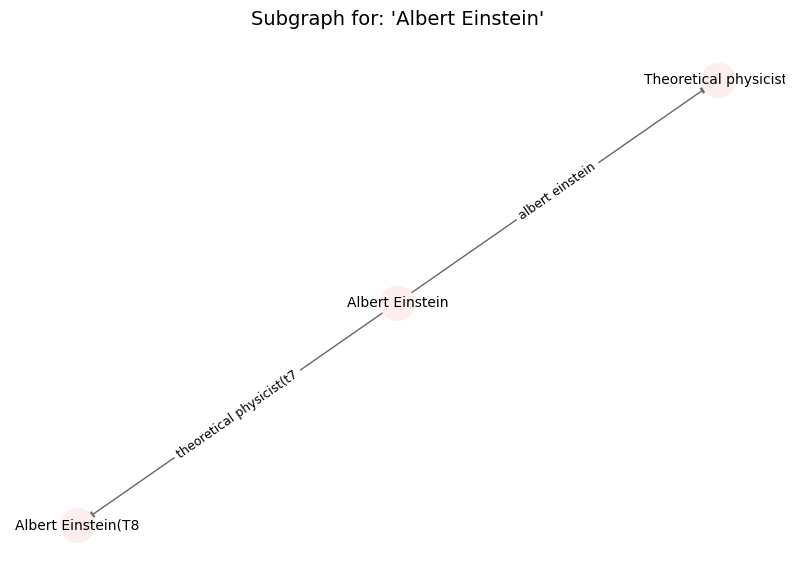

In [77]:
# Example: Ask a question about a historical figure's contribution.
question = "How did Albert Einstein contribute to the development of the atomic bomb?"
# Set the depth for the subgraph search
depth= 2
retrieved_chunks, response = answer_question_with_graph(question, depth)

print("\nRetrieved Chunks:")
for line in retrieved_chunks:
    print("-", line)

print("\nAnswer:")
print(response)

visualize_subgraph(question, depth)

# Learner Prompt:
# - Try changing the question or the depth. What do you notice about the retrieved facts and the answer?

In [78]:
# Print all nodes (entities) in the knowledge graph.
print(list(G.nodes))

# Learner Prompt:
# - How many entities are in your graph? Are there any you didn't expect to see?

['Einstein', 'Albert', 'Marie Curie', 'significantly advancing radioactivity research.', 'Albert Einstein', 'Theoretical physicist.', 'Subject1', 'Predicate1', 'Subject2', 'Predicate2', 'Object1', 'Object2', 'Polonium', 'Radium', 'Subject3', 'Subject4', 'Theoretical physicist', 'Subject5', 'Galileo Galilei', 'Subject6', 'Heliocentrism', 'Subject7', 'Subject8', 'heliocentesis', 'Object3', 'Object4', 'SubjectT1', 'ObjectT1', 'SubjectT2', 'ObjectT2', 'Albert Einstein(T8', 'Polonium(T1', 'Radium(T3']


In [79]:
# Print all edges related to 'relativity' to explore specific relationships in the graph.
for u, v, data in G.edges(data=True):
    if "relativity" in u.lower() or "relativity" in v.lower():
        print(f"{u} --{data['relation']}--> {v}")

# Learner Prompt:
# - Try searching for other keywords or relationships. What patterns or connections do you discover?